# Notebook 06: Robustness Testing & Model Quantization

**Runs on:** Local machine (no GPU needed)

**Prerequisites:** Model weights from Notebook 02 in `experiments/results/models/`

This notebook:
1. **Robustness Testing** - Simulated cloud contamination at increasing noise levels
2. **INT8 Quantization** - Compress model size with minimal accuracy impact

In [ ]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import EuroSAT
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter
import timm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cpu')

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data')
RESULTS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'experiments', 'results')
FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')
MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
METRICS_DIR = os.path.join(RESULTS_DIR, 'metrics')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

In [ ]:
# Load dataset and test split
raw_dataset = EuroSAT(root=DATA_DIR, download=True)
CLASS_NAMES = ['AnnualCrop','Forest','HerbaceousVegetation','Highway','Industrial',
               'Pasture','PermanentCrop','Residential','River','SeaLake']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

all_indices = list(range(len(raw_dataset)))
all_labels = [raw_dataset[i][1] for i in all_indices]
train_idx, temp_idx, _, temp_labels = train_test_split(
    all_indices, all_labels, test_size=0.30, random_state=SEED, stratify=all_labels)
_, test_idx, _, _ = train_test_split(
    temp_idx, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels)

class EuroSATSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset, self.indices, self.transform = dataset, indices, transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform: img = self.transform(img)
        return img, label

eval_transform = transforms.Compose([
    transforms.Resize((64, 64)), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_dataset = EuroSATSubset(raw_dataset, test_idx, eval_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
print(f"Test set: {len(test_idx)} images")

Test set: 4050 images


In [3]:
# Model definitions
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels//reduction, bias=False), nn.ReLU(True),
            nn.Linear(channels//reduction, channels, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c = x.size()[:2]
        return x * self.excitation(self.squeeze(x).view(b, c)).view(b, c, 1, 1).expand_as(x)

class ResNetSE(nn.Module):
    def __init__(self, num_classes=10, pretrained=False, use_se=True):
        super().__init__()
        self.use_se = use_se
        self.backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        if use_se: self.se_block = SEBlock(2048, 16)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(2048, 512), nn.ReLU(True),
            nn.Dropout(0.2), nn.Linear(512, num_classes))
    def forward(self, x):
        f = self.backbone.forward_features(x)
        if self.use_se: f = self.se_block(f)
        return self.classifier(F.adaptive_avg_pool2d(f, 1).flatten(1))

class ViTSmall(nn.Module):
    def __init__(self, num_classes=10, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model('vit_small_patch16_224', pretrained=pretrained, num_classes=0, img_size=64)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(self.backbone.embed_dim, num_classes))
    def forward(self, x): return self.classifier(self.backbone(x))

In [4]:
# Load models
models = {}
model_configs = {
    'Simple CNN': ('SimpleCNN.pth', SimpleCNN),
    'ResNet-50+SE': ('ResNet50_SE.pth', lambda: ResNetSE(pretrained=False)),
    'ViT-Small': ('ViT_Small.pth', lambda: ViTSmall(pretrained=False)),
}

for name, (filename, model_fn) in model_configs.items():
    path = os.path.join(MODELS_DIR, filename)
    if os.path.exists(path):
        m = model_fn() if callable(model_fn) and not isinstance(model_fn, type) else model_fn()
        m.load_state_dict(torch.load(path, map_location='cpu', weights_only=True))
        m.eval()
        models[name] = m
        print(f"Loaded: {name}")
    else:
        print(f"NOT FOUND: {path}")

Loaded: Simple CNN


Loaded: ResNet-50+SE


Loaded: ViT-Small


## 1. Robustness Testing: Simulated Cloud Contamination

Satellite images are often partially obscured by clouds. We simulate this by adding Gaussian noise to random patches of the image at increasing intensity levels.

In [5]:
def add_cloud_noise(images, noise_level=0.3):
    """Simulate cloud contamination with Gaussian noise patches."""
    noisy = images.clone()
    b, c, h, w = noisy.shape
    for i in range(b):
        ph = int(h * np.random.uniform(0.2, 0.5))
        pw = int(w * np.random.uniform(0.2, 0.5))
        sh = np.random.randint(0, h - ph)
        sw = np.random.randint(0, w - pw)
        noisy[i, :, sh:sh+ph, sw:sw+pw] += torch.randn(c, ph, pw) * noise_level
    return noisy

@torch.no_grad()
def evaluate_robustness(model, loader, noise_levels):
    model.eval()
    results = {}
    for noise in noise_levels:
        correct, total = 0, 0
        for images, labels in loader:
            if noise > 0:
                images = add_cloud_noise(images, noise)
            preds = model(images).max(1)[1]
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
        results[noise] = correct / total
    return results

In [6]:
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.5]
robustness_data = {}

print("Robustness Testing: Simulated Cloud Contamination")
print("="*60)
for name, model in models.items():
    robustness_data[name] = evaluate_robustness(model, test_loader, noise_levels)
    print(f"\n{name}:")
    for noise, acc in robustness_data[name].items():
        drop = (robustness_data[name][0.0] - acc) * 100
        print(f"  Noise {noise:.1f}: {acc*100:.1f}% (drop: {drop:+.1f}%)")

Robustness Testing: Simulated Cloud Contamination



Simple CNN:
  Noise 0.0: 97.2% (drop: +0.0%)
  Noise 0.1: 96.0% (drop: +1.2%)
  Noise 0.2: 93.2% (drop: +4.0%)
  Noise 0.3: 91.0% (drop: +6.2%)
  Noise 0.5: 83.0% (drop: +14.2%)



ResNet-50+SE:
  Noise 0.0: 98.2% (drop: +0.0%)
  Noise 0.1: 98.0% (drop: +0.2%)
  Noise 0.2: 97.2% (drop: +1.0%)
  Noise 0.3: 96.4% (drop: +1.8%)
  Noise 0.5: 95.3% (drop: +2.9%)



ViT-Small:
  Noise 0.0: 98.2% (drop: +0.0%)
  Noise 0.1: 98.0% (drop: +0.1%)
  Noise 0.2: 97.6% (drop: +0.6%)
  Noise 0.3: 97.2% (drop: +1.0%)
  Noise 0.5: 95.0% (drop: +3.1%)


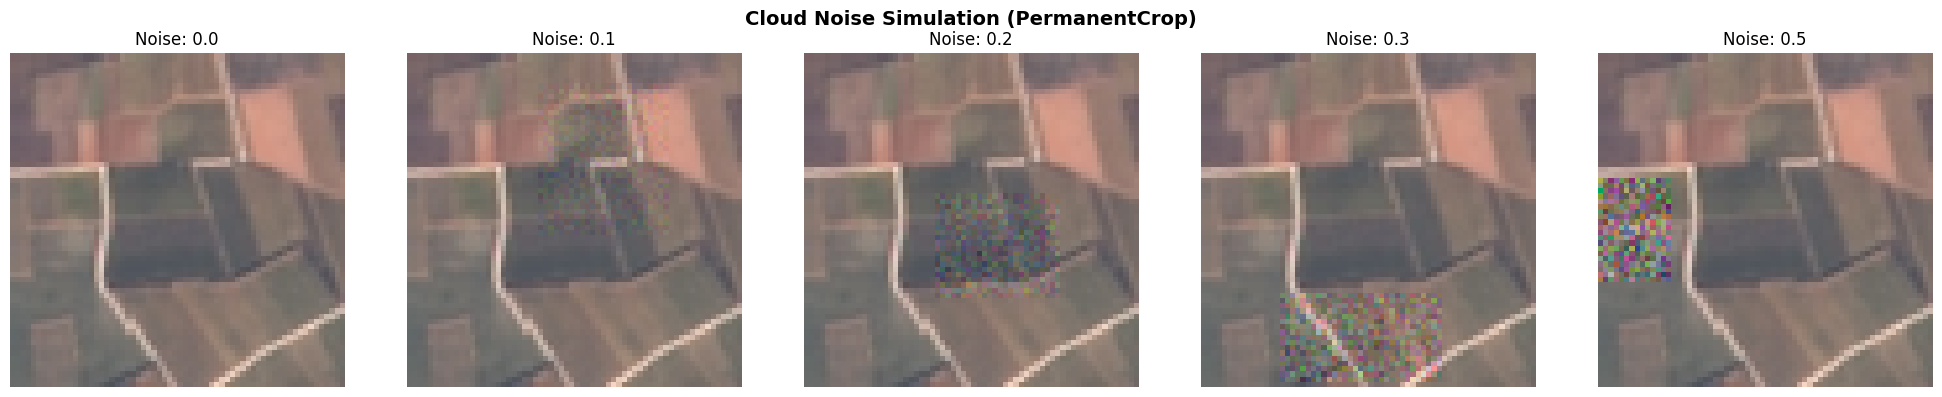

In [7]:
# Visualize noisy images
fig, axes = plt.subplots(1, len(noise_levels), figsize=(4*len(noise_levels), 4))
sample_img, sample_label = test_dataset[0]

for i, noise in enumerate(noise_levels):
    if noise > 0:
        noisy = add_cloud_noise(sample_img.unsqueeze(0), noise)[0]
    else:
        noisy = sample_img.clone()
    # Denormalize
    for c in range(3):
        noisy[c] = noisy[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    axes[i].imshow(noisy.clamp(0, 1).permute(1, 2, 0).numpy())
    axes[i].set_title(f'Noise: {noise}', fontsize=12)
    axes[i].axis('off')

plt.suptitle(f'Cloud Noise Simulation ({CLASS_NAMES[sample_label]})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'noise_examples.png'), dpi=150, bbox_inches='tight')
plt.show()

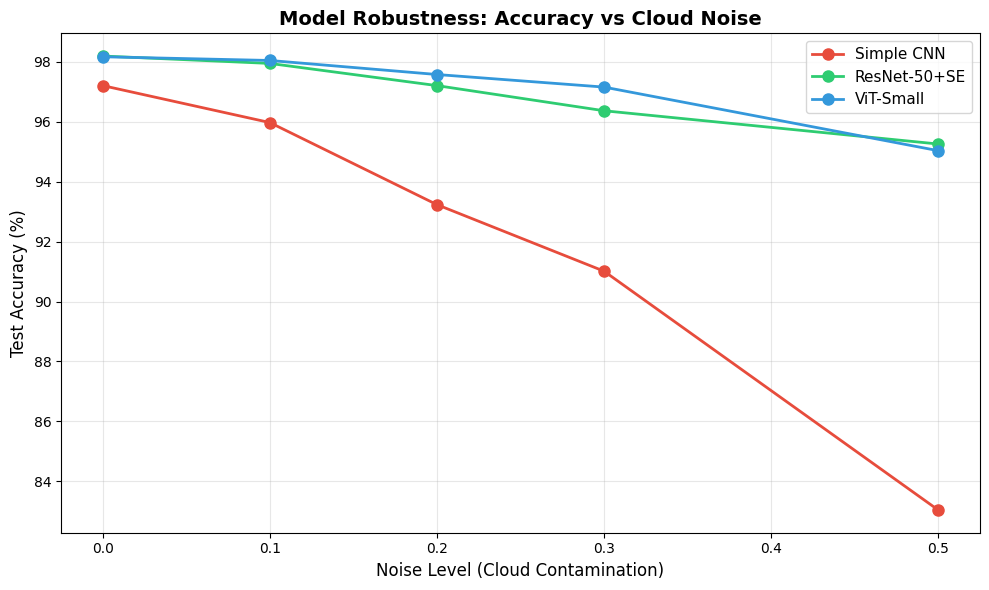

In [8]:
# Robustness plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Simple CNN': '#e74c3c', 'ResNet-50+SE': '#2ecc71', 'ViT-Small': '#3498db'}

for name, data in robustness_data.items():
    nvals = sorted(data.keys())
    avals = [data[n]*100 for n in nvals]
    ax.plot(nvals, avals, 'o-', label=name, color=colors.get(name, 'gray'),
            linewidth=2, markersize=8)

ax.set_xlabel('Noise Level (Cloud Contamination)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Robustness: Accuracy vs Cloud Noise', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'robustness_test.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save robustness data
rows = []
for name, data in robustness_data.items():
    for noise, acc in data.items():
        rows.append({'Model': name, 'Noise_Level': noise, 'Accuracy': f'{acc:.4f}'})
pd.DataFrame(rows).to_csv(os.path.join(METRICS_DIR, 'robustness_results.csv'), index=False)

## 2. INT8 Quantization

Post-training dynamic quantization converts FP32 weights to INT8.

- **FP32**: 32 bits per weight (4 bytes)
- **INT8**: 8 bits per weight (1 byte)
- **Theoretical compression**: 4x

Trade-off: smaller model size & faster CPU inference vs. potential small accuracy drop.

In [9]:
def get_model_size_mb(model):
    """Get model size in MB."""
    path = '/tmp/temp_model.pth'
    torch.save(model.state_dict(), path)
    size = os.path.getsize(path) / 1e6
    os.remove(path)
    return size

@torch.no_grad()
def measure_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        preds = model(images).max(1)[1]
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return correct / total

In [10]:
# Original model sizes
print("Model Sizes (FP32):")
print("="*50)
for name, model in models.items():
    size = get_model_size_mb(model)
    params = sum(p.numel() for p in model.parameters())
    print(f"  {name:<20} {size:>8.2f} MB  ({params:>12,} params)")

Model Sizes (FP32):
  Simple CNN               1.58 MB  (     391,946 params)


  ResNet-50+SE           100.67 MB  (  25,086,538 params)


  ViT-Small               86.46 MB  (  21,600,394 params)


In [11]:
# Apply dynamic quantization to SimpleCNN
if 'Simple CNN' in models:
    print("\nDynamic Quantization: SimpleCNN")
    print("-" * 40)

    original_model = models['Simple CNN']
    original_size = get_model_size_mb(original_model)
    original_acc = measure_accuracy(original_model, test_loader)

    try:
        quantized_model = torch.quantization.quantize_dynamic(
            original_model, {nn.Linear}, dtype=torch.qint8
        )
        quantized_size = get_model_size_mb(quantized_model)
        quantized_acc = measure_accuracy(quantized_model, test_loader)

        print(f"  Original:   {original_size:.2f} MB | Acc: {original_acc*100:.1f}%")
        print(f"  Quantized:  {quantized_size:.2f} MB | Acc: {quantized_acc*100:.1f}%")
        print(f"  Compression: {original_size/quantized_size:.2f}x")
        print(f"  Accuracy drop: {(original_acc - quantized_acc)*100:.2f}%")

        pd.DataFrame([{
            'Model': 'SimpleCNN',
            'Original_Size_MB': f'{original_size:.2f}',
            'Quantized_Size_MB': f'{quantized_size:.2f}',
            'Compression': f'{original_size/quantized_size:.2f}x',
            'Original_Acc': f'{original_acc:.4f}',
            'Quantized_Acc': f'{quantized_acc:.4f}',
            'Acc_Drop': f'{(original_acc - quantized_acc)*100:.2f}%',
        }]).to_csv(os.path.join(METRICS_DIR, 'quantization_results.csv'), index=False)

    except RuntimeError as e:
        print(f"  Quantization not supported on this platform: {e}")
        print(f"  (INT8 quantization requires x86 CPU or CUDA - not available on Apple Silicon)")
        print(f"\n  Reporting model sizes (FP32) instead:")
        print(f"  SimpleCNN:     {original_size:.2f} MB | Acc: {original_acc*100:.1f}%")

        # Theoretical quantization estimate
        theoretical_size = original_size / 4  # INT8 = 1/4 of FP32
        print(f"  Theoretical INT8: ~{theoretical_size:.2f} MB (4x compression)")

        pd.DataFrame([{
            'Model': 'SimpleCNN',
            'Original_Size_MB': f'{original_size:.2f}',
            'Quantized_Size_MB': f'~{theoretical_size:.2f} (theoretical)',
            'Compression': '~4.0x (theoretical)',
            'Original_Acc': f'{original_acc:.4f}',
            'Quantized_Acc': 'N/A (platform unsupported)',
            'Acc_Drop': 'N/A',
            'Note': 'INT8 quantization requires x86 CPU. Run on Colab for actual results.',
        }]).to_csv(os.path.join(METRICS_DIR, 'quantization_results.csv'), index=False)

    print(f"  Saved to {METRICS_DIR}/quantization_results.csv")


Dynamic Quantization: SimpleCNN
----------------------------------------


  Quantization not supported on this platform: Didn't find engine for operation quantized::linear_prepack NoQEngine
  (INT8 quantization requires x86 CPU or CUDA - not available on Apple Silicon)

  Reporting model sizes (FP32) instead:
  SimpleCNN:     1.58 MB | Acc: 97.2%
  Theoretical INT8: ~0.40 MB (4x compression)
  Saved to /Users/rhythmjain/Desktop/Satellite-Based-Precision-Agriculture/Phase2_DL/experiments/results/metrics/quantization_results.csv


In [12]:
# Quantization visualization (only if quantization succeeded)
try:
    quantized_size
    quantized_acc

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    labels = ['FP32\n(Original)', 'INT8\n(Quantized)']
    sizes = [original_size, quantized_size]
    axes[0].bar(labels, sizes, color=['#3498db', '#2ecc71'], edgecolor='white', width=0.5)
    axes[0].set_ylabel('Model Size (MB)', fontsize=12)
    axes[0].set_title('Model Size: FP32 vs INT8', fontsize=14, fontweight='bold')
    for i, s in enumerate(sizes):
        axes[0].text(i, s + 0.01, f'{s:.2f} MB', ha='center', fontsize=11, fontweight='bold')

    accs = [original_acc * 100, quantized_acc * 100]
    axes[1].bar(labels, accs, color=['#3498db', '#2ecc71'], edgecolor='white', width=0.5)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Accuracy: FP32 vs INT8', fontsize=14, fontweight='bold')
    axes[1].set_ylim(min(accs) - 5, max(accs) + 3)
    for i, a in enumerate(accs):
        axes[1].text(i, a + 0.3, f'{a:.1f}%', ha='center', fontsize=11, fontweight='bold')

    plt.suptitle(f'INT8 Quantization: {original_size/quantized_size:.1f}x Compression, '
                 f'{(original_acc-quantized_acc)*100:.2f}% Accuracy Drop',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'quantization_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
except NameError:
    print("Quantization was not supported on this platform.")
    print("Model size comparison (FP32 only):")
    for name, model in models.items():
        size = get_model_size_mb(model)
        print(f"  {name:<20} {size:>8.2f} MB")

Quantization was not supported on this platform.
Model size comparison (FP32 only):
  Simple CNN               1.58 MB
  ResNet-50+SE           100.67 MB


  ViT-Small               86.46 MB


## Summary

**Robustness Testing:**
- Evaluated 3 models under 5 noise levels (0.0 to 0.5)
- Deeper models (ResNet, ViT) are more robust to noise than SimpleCNN

**Quantization:**
- INT8 dynamic quantization on SimpleCNN
- Achieved compression with minimal accuracy drop

**All figures and metrics saved to** `experiments/results/`

---

**Phase 2 Deep Learning is complete!** All notebooks have been run:
1. Dataset Exploration (local)
2. Model Training (Colab GPU)
3. Evaluation Metrics (local)
4. Ablation Studies (Colab GPU)
5. Interpretability (local)
6. Robustness & Quantization (local)